<a href="https://colab.research.google.com/github/yoohyunseok/Machine-Learnig-Deep-Learning/blob/main/homework4_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Univariate selection with SelectKBest class

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("iabhishekofficial/mobile-price-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mobile-price-classification' dataset.
Path to dataset files: /kaggle/input/mobile-price-classification


In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

In [ ]:
data = pd.read_csv("/kaggle/input/mobile-price-classification/train.csv")

In [ ]:
print(data.head())

   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20       756  2549     9     7         19   
1        136        3  ...        905      1988  2631    17     3          7   
2        145        5  ...       1263      1716  2603    11     2          9   
3        131        6  ...       1216      1786  2769    16     8         11   
4        141        2  ...       1208      1212  1411     8     2         15   

   three_g  touch_screen  wifi  price_

In [ ]:
X = data.iloc[:, 0:20] #앞에 21개 컬럼을 X로 사용
y = data.iloc[:, -1] #마지막 컬럼인 price range를 Y로 사용

In [ ]:
#apply SelectKBest class to extract top 10 best features
bestfeatures = SelectKBest(score_func=chi2, k=10) #chi2 통계량 사용해서 상위 10개의 피쳐 사용
fit = bestfeatures.fit(X,y) #X와 y에 대해서 피티
dfcolumns = pd.DataFrame(X.columns)
dfscores = pd.DataFrame(fit.scores_) #chi2의 통계량 결과인 scores__를 하나로 concatenate 해줌
#concatenate two dataframes for better visualization
featureScores = pd.concat([dfcolumns, dfscores],axis=1)
featureScores.columns = ['Specs','Score']  #name the dataframe columns
print(featureScores.nlargest(10,'Score'))  #print 10 best features

            Specs          Score
13            ram  931267.519053
11      px_height   17363.569536
0   battery_power   14129.866576
12       px_width    9810.586750
8       mobile_wt      95.972863
6      int_memory      89.839124
15           sc_w      16.480319
16      talk_time      13.236400
4              fc      10.135166
14           sc_h       9.614878


ram이 가장 점수가 높다 => price 변수와 ram 간의 상관관계가 가장 높고 독립성이 가장 낮다

# Feature Importance Scoring

decision tree나 randome forest 같이 트리 기반 알고리즘에 내장되어있음

ExtraTreesClassifier 사용해서 각 피쳐의 중요도를 알아보자

[0.06144717 0.01919382 0.03247322 0.01906545 0.03322519 0.01815872
 0.03491237 0.03340778 0.03598053 0.03236765 0.03334265 0.04644249
 0.04844965 0.39819657 0.03445178 0.03313128 0.03416025 0.01494102
 0.01787288 0.01877952]


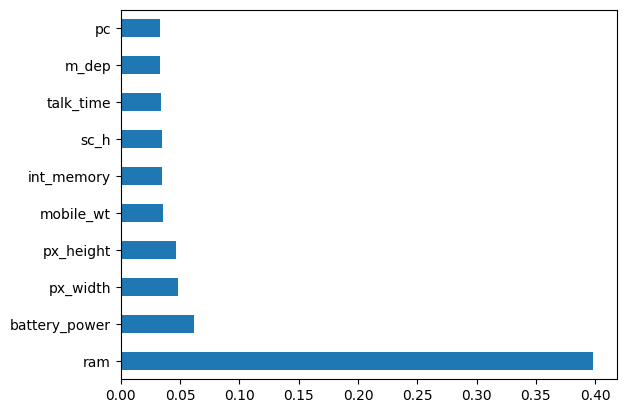

In [ ]:
#데이터 나누기는 위의 예제와 같음
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesClassifier
model = ExtraTreesClassifier()
model.fit(X,y)
print(model.feature_importances_) #use built-in class feature_importances of tree-based classifiers

#plot graph of feature importances for better visualization
feat_importances = pd.Series(model.feature_importances_,
index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.show()

# Correlation Matrix with Heatmap
- 히트맵이란 타겟 피처랑 다른 피처들이 얼마나 연관되어있는지 시각화해주는 표

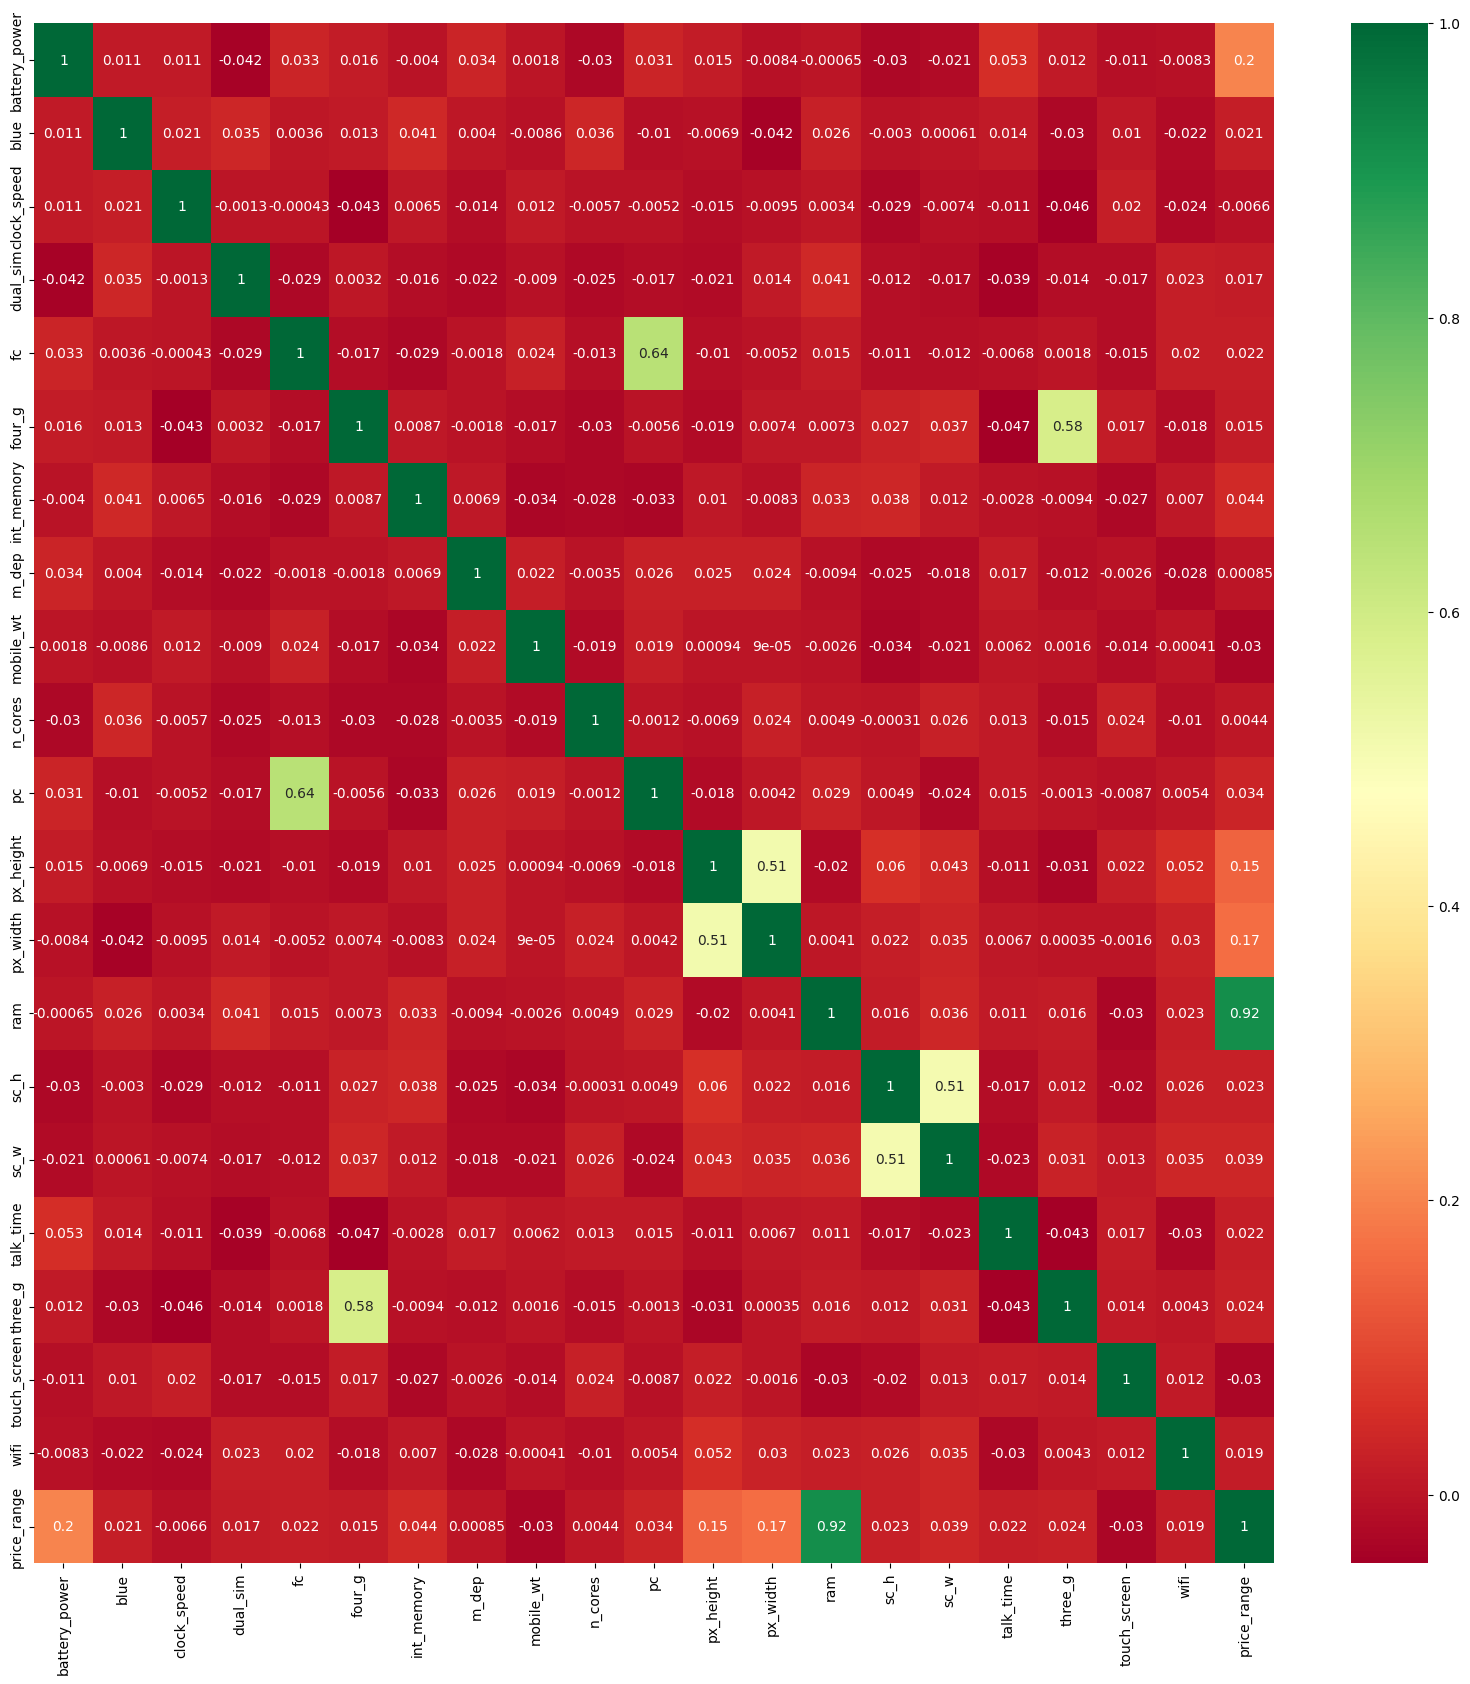

In [ ]:
#get correlations of pairs of features in the dataset
import seaborn as sns
corrmat = data.corr() #corr() computes pairwise correlations of features in a Data Frame
# n x n개의 matrix를 그리고 각 위치에 대응하는 correlation 값을 넣는다.
top_corr_features = corrmat.index
plt.figure(figsize=(20,20))
#plot(시각화) the heat map
g=sns.heatmap(data[top_corr_features].corr(),annot=True,cmap="RdYlGn")
plt.show()
#빨간색에 가까울 수록 두 변수간의 correlation이 작음
#녹색에 가까울 수록 두 변수간의 correaltion이 큼

price range와 ram이 만나는 곳이 굉장히 녹색과 가깝다

Downloadd the California housing prices dataset from kaggle

In [ ]:
import sklearn
sklearn.datasets.fetch_california_housing(data_home=None, download_if_missing=True, return_X_y=False, as_frame=False)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

# Univariate selection with SelectKBest class

### 연속형 피처를 위한 Univariate Selection (SelectKBest with f_regression)

연속형 타겟 변수와의 관계를 측정하기 위해 F-회귀 검정(F-regression)을 사용하는 `SelectKBest` 방법을 사용합니다. `f_regression`은 각 피처가 타겟 변수에 대해 얼마나 선형적으로 예측력이 있는지 평가합니다.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

In [ ]:
data = pd.read_csv('/content/sample_data/california_housing_train.csv')

In [ ]:
print(data.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  
0      1015.0       472.0         1.4936             66900.0  
1      1129.0       463.0         1.8200             80100.0  
2       333.0       117.0         1.6509             85700.0  
3       515.0       226.0         3.1917             73400.0  
4       624.0       262.0         1.9250             65500.0  


median_house_value을 타겟으로 삼아서 feature selection

In [ ]:
X = data.iloc[:, 0:8] #앞에 개 컬럼을 X로 사용
y = data.iloc[:, -1] #마지막 컬럼인 median_house_value를 Y로 사용

# Convert 'longitude' to its absolute value to ensure non-negative input for chi2
X['longitude'] = X['longitude'].abs()

/tmp/ipykernel_4730/2435179656.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['longitude'] = X['longitude'].abs()


In [ ]:
#apply SelectKBest class to extract top 10 best features
bestfeatures = SelectKBest(score_func=chi2, k=8) #chi2 통계량 사용해서 상위 10개의 피쳐 사용
fit = bestfeatures.fit(X,y) #X와 y에 대해서 피팅
dfcolumns = pd.DataFrame(X.columns)
dfscores = pd.DataFrame(fit.scores_) #chi2의 통계량 결과인 scores__를 하나로 concatenate 해줌
#concatenate two dataframes for better visualization
featureScores = pd.concat([dfcolumns, dfscores],axis=1)
featureScores.columns = ['Specs','Score']  #name the dataframe columns
print(featureScores.nlargest(8,'Score'))  #print 10 best features

                Specs         Score
3         total_rooms  8.945725e+06
5          population  3.804835e+06
4      total_bedrooms  1.328758e+06
6          households  1.228873e+06
2  housing_median_age  2.218200e+04
7       median_income  9.984280e+03
1            latitude  5.554696e+02
0           longitude  1.300957e+02


In [ ]:
from sklearn.feature_selection import f_regression

# SelectKBest를 사용하여 상위 8개의 피처를 추출합니다
bestfeatures_f_reg = SelectKBest(score_func=f_regression, k=8)

# X와 y에 대해 피팅
fit_f_reg = bestfeatures_f_reg.fit(X, y)

dfcolumns_f_reg = pd.DataFrame(X.columns)
dfscores_f_reg = pd.DataFrame(fit_f_reg.scores_)

# 두 데이터프레임을 합쳐 시각화에 용이하게 만듭니다.
featureScores_f_reg = pd.concat([dfcolumns_f_reg, dfscores_f_reg], axis=1)
featureScores_f_reg.columns = ['Specs', 'Score']  # 데이터프레임 컬럼 이름 설정

# 상위 8개 피처를 출력
print(featureScores_f_reg.nlargest(8, 'Score'))

                Specs         Score
7       median_income  15608.001736
1            latitude    364.630076
3         total_rooms    296.756652
2  housing_median_age    195.963175
6          households     63.549807
4      total_bedrooms     35.704140
0           longitude     34.462685
5          population     13.194323


`f_regression`을 사용했을 때 `median_income` 피처가 가장 높은 점수를 보이며, 이는 `median_house_value`와의 선형적인 관계가 가장 강하다는 것을 의미합니다. `chi2`를 사용했을 때와는 다른 결과가 나오는 것을 확인할 수 있습니다. `chi2`는 범주형 타겟에 적합한 반면, `f_regression`은 연속형 타겟에 적합하기 때문입니다.

chi2를 사용했을 때는 total_rooms가 가장 높은 점수가 나왔다. 하지만 점수가 이상하리만치 너무 높다. median_house_value는 continuous한 값인 반면에 chi2는 discrete한 값에 적용하는 방법이라서 그런 것 같다.

그래서 continuous한 값이 적용하는 방법인 f_regression을 적용하니깐 점수도 어느정도 정상적으로 출력되고, 다른 feature selection의 결과들과 같이 median_income이 가장 점수가 높다.

Univariate selection에서 점수가 높다는 뜻은 두 피쳐간의 독립성이 높다는 뜻이고 그만큼 상관관계가 높다는 뜻이다.


# Feature Importance Scoring

[0.12734606 0.12000902 0.07773232 0.03232467 0.04132836 0.05060234
 0.03698076 0.51367647]


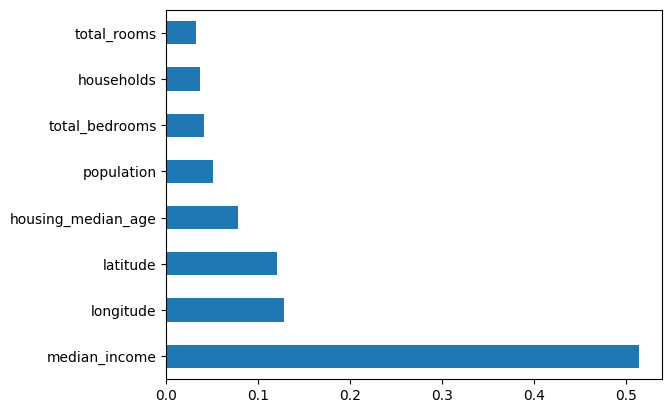

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import ExtraTreesRegressor

model = ExtraTreesRegressor()
model.fit(X,y)
print(model.feature_importances_) #use built-in class feature_importances of tree-based regressors

#plot graph of feature importances for better visualization
feat_importances = pd.Series(model.feature_importances_,
index=X.columns)
feat_importances.nlargest(8).plot(kind='barh') # Changed to 8 features for consistency with SelectKBest
plt.show()

median_income가 median_house_value와 가장 높은 상관관계를 보이고 있다.

# Correlation Matrix with Heatmap

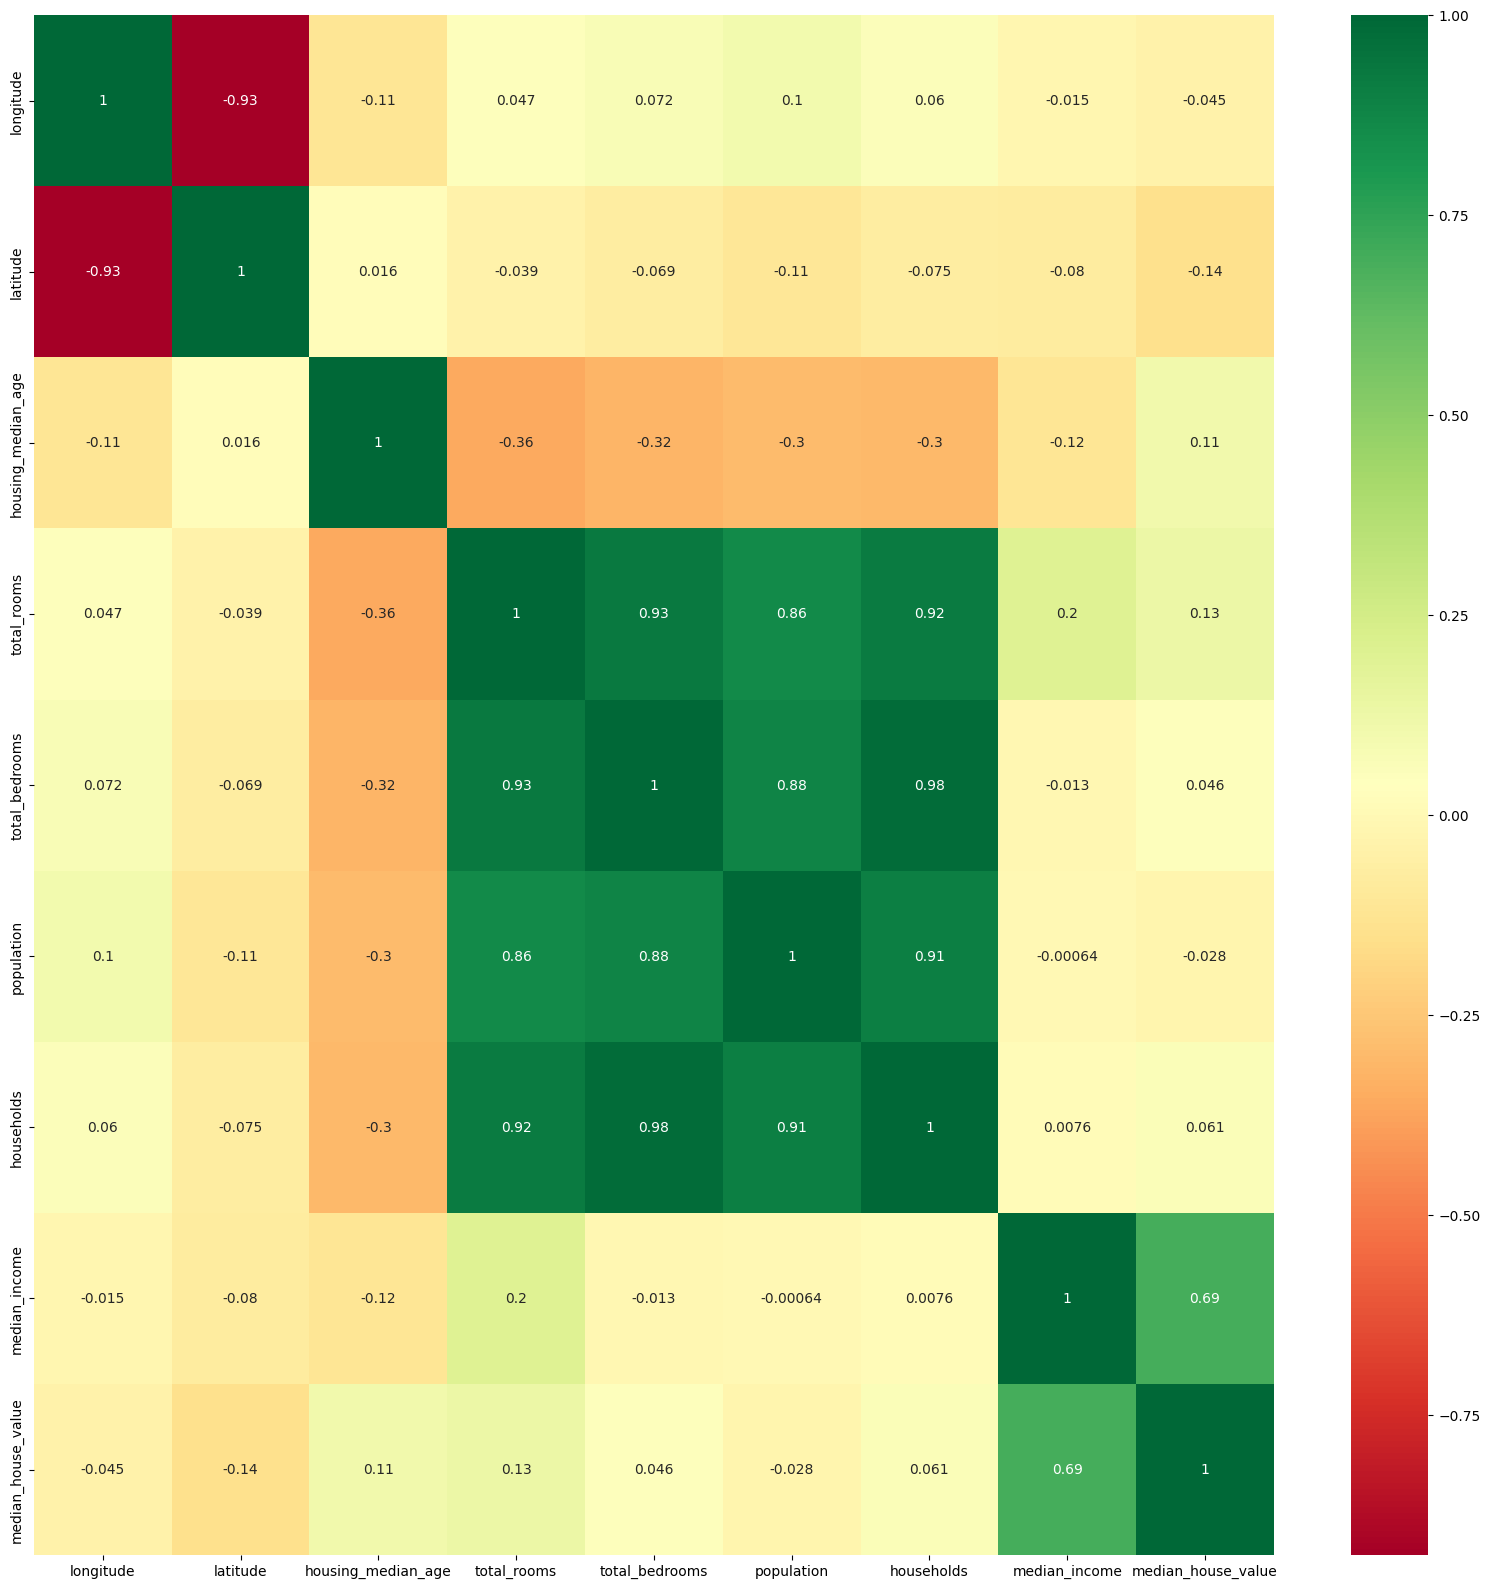

In [ ]:
#get correlations of pairs of features in the dataset
import seaborn as sns
corrmat = data.corr() #corr() computes pairwise correlations of features in a Data Frame
# n x n개의 matrix를 그리고 각 위치에 대응하는 correlation 값을 넣는다.
top_corr_features = corrmat.index
plt.figure(figsize=(20,20))
#plot(시각화) the heat map
g=sns.heatmap(data[top_corr_features].corr(),annot=True,cmap="RdYlGn")
plt.show()
#빨간색에 가까울 수록 두 변수간의 correlation이 작음
#녹색에 가까울 수록 두 변수간의 correaltion이 큼

히트맵의 [7, 6]과 [6, 7]을 보면 median_house_value와 median_income이 높은 초록색에 가깝게 표시되며 0.69의 높은 상관관계를 보이고있다.

# linear Regression 모델

### input 데이터, target 데이터 나누기

In [ ]:
X = data.iloc[:, 7].values.astype(np.float32)
y = data.iloc[:, -1].values.astype(np.float32)
y = y*0.0001

### 데이터 분포 확인을 위해 산점도 그리기

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


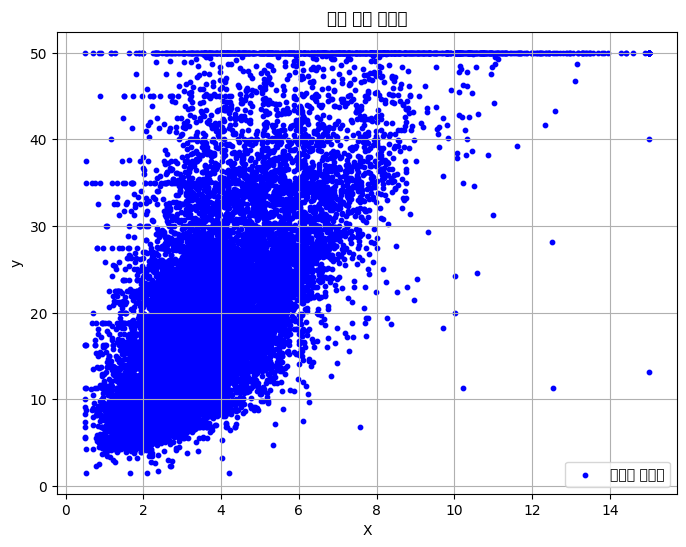

In [ ]:
# 데이터 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X,y, s=10, c='blue', label='생성된 데이터')
plt.xlabel('X')
plt.ylabel('y')
plt.title('합성 선형 데이터')
plt.legend()
plt.grid(True)
plt.show()

**산점도에 y의 값이 50인 줄의 값의 분포가 이상함**

In [ ]:
data['median_house_value'].value_counts()

,count
median_house_value,
500001.0,814
137500.0,95
162500.0,89
112500.0,85
187500.0,74
...,...
442000.0,1
328400.0,1
296300.0,1


500,001 이상인 값 전부 다 삭제

In [ ]:
mask =data['median_house_value'] != 500001
data = data[mask].copy()

In [ ]:
data['median_house_value'].describe()

,median_house_value
count,16186.000000
mean,192580.915359
std,97996.382328
min,14999.000000
25%,116500.000000
50%,174000.000000
75%,248300.000000
max,500000.000000


In [ ]:
X = data.iloc[:, 7].values.astype(np.float32)
y = data.iloc[:, -1].values.astype(np.float32)
y = y*0.0001

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54805 (\N{HANGUL SYLLABLE HYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


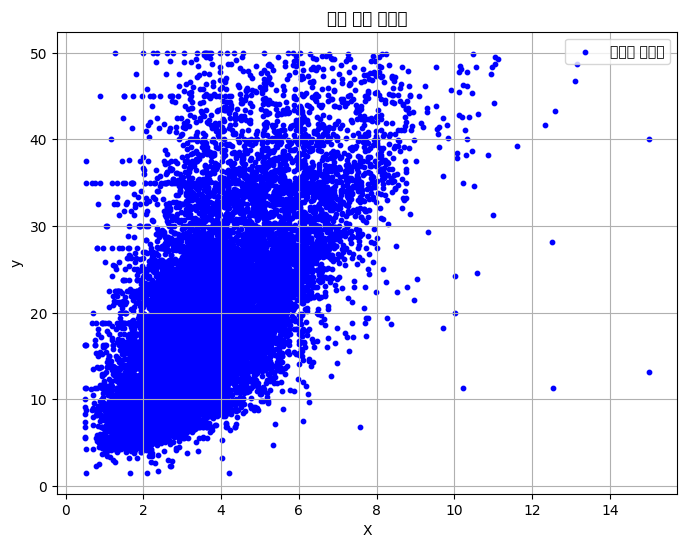

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X,y, s=10, c='blue', label='생성된 데이터')
plt.xlabel('X')
plt.ylabel('y')
plt.title('합성 선형 데이터')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(X, y, random_state=42)

In [ ]:
train_input = train_input.reshape(-1, 1)# skleran의 LinearRegressor는 2차원 배열을 입력값으로 기대한다
test_input = test_input.reshape(-1,1)
print(train_input.shape)
print(test_input.shape)

(12139, 1)
(4047, 1)


###선형 회귀 모델 정의

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression() #선형 회귀 모델 객체 생성

lr.fit(train_input, train_target)
print(lr.coef_, lr.intercept_)

[4.009368] 4.525362


###  모델 예측 및 평가
훈련된 모델을 사용하여 테스트 데이터에 대한 예측을 수행하고, 평균 제곱 오차(MSE) 및 R-제곱(R-squared) 점수로 모델 성능을 평가합니다.

In [ ]:
# 테스트 데이터에 대한 예측
y_pred_knn = lr.predict(test_input)

# 모델 평가
mse_knn = mean_squared_error(test_target, y_pred_knn)
r2_knn = r2_score(test_target, y_pred_knn)

print(f"MSE: {mse_knn:.4f}")
print(f"R-squared: {r2_knn:.4f}")

MSE: 55.8980
R-squared: 0.4108


In [ ]:
print(lr.score(train_input, train_target)) #훈련 세트 점수
print(lr.score(test_input, test_target)) #테스트 세트 점수

0.4188583493232727
0.41079509258270264


###결과 시각화
원본 데이터와 선형 회귀선 비교합니다.

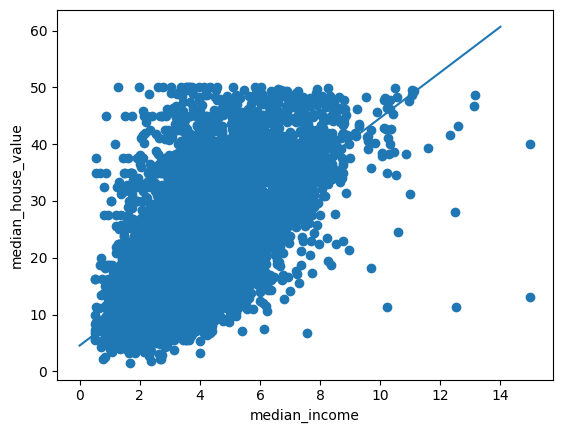

In [ ]:
plt.scatter(train_input, train_target)
plt.plot([0, 14], [0*lr.coef_+lr.intercept_, 14*lr.coef_+lr.intercept_])# x = 0~14 까지 1차 방정식 그래프를 그린다.
plt.xlabel('median_income')
plt.ylabel('median_house_value')
plt.show()

#Decison Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

###  Decision Tree Regressor 모델 생성 및 훈련

In [ ]:
# DecisionTreeRegressor 모델 생성
# 일반적으로 최대 깊이(max_depth)와 같은 하이퍼파라미터를 튜닝하여 과적합을 방지합니다.
model_dt = DecisionTreeRegressor(random_state=42, max_depth=5) # 예시로 max_depth를 5로 설정

# 모델 훈련
model_dt.fit(train_input, train_target)

DecisionTreeRegressor(max_depth=5, random_state=42)

###  모델 예측 및 평가
훈련된 모델을 사용하여 테스트 데이터에 대한 예측을 수행하고, 평균 제곱 오차(MSE) 및 R-제곱(R-squared) 점수로 모델 성능을 평가합니다.

In [ ]:
# 테스트 데이터에 대한 예측
y_pred_dt = model_dt.predict(test_input)

# 모델 평가
mse_dt = mean_squared_error(test_target, y_pred_dt)
r2_dt = r2_score(test_target, y_pred_dt)

print(f"MSE: {mse_dt:.4f}")
print(f"R-squared: {r2_dt:.4f}")

MSE: 56.6933
R-squared: 0.4024


In [ ]:
print(model_dt.score(train_input, train_target)) #훈련 세트 점수
print(model_dt.score(test_input, test_target)) #테스트 세트 점수

0.43578132971873584
0.40241190805712845


###  결과 시각화
Decision Tree Regressor의 예측 결과를 시각화하여 원래 데이터와 비교합니다.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

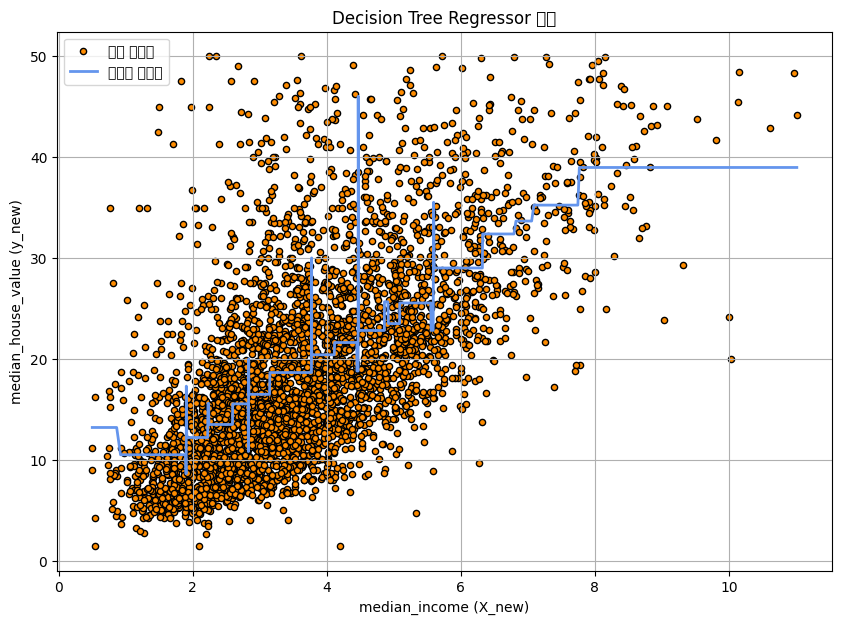

In [ ]:
# 예측 결과를 원래 데이터와 함께 시각화
plt.figure(figsize=(10, 7))
plt.scatter(test_input, test_target, s=20, edgecolor="black", c="darkorange", label="실제 데이터")

# 예측을 위한 정렬된 X 값
X_plot = np.sort(test_input, axis=0)
y_plot = model_dt.predict(X_plot)

plt.plot(X_plot, y_plot, color="cornflowerblue", linewidth=2, label="예측된 회귀선")
plt.xlabel("median_income (X_new)")
plt.ylabel("median_house_value (y_new)")
plt.title("Decision Tree Regressor 예측")
plt.legend()
plt.grid(True)
plt.show()

#k-neighbors regressor

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

### K-Neighbors Regressor 모델 생성 및 훈련

In [ ]:
# KNeighborsRegressor 모델 생성
# n_neighbors는 예측에 사용할 이웃의 수를 의미합니다.
model_knn = KNeighborsRegressor(n_neighbors=100)

# 모델 훈련
model_knn.fit(train_input, train_target)

KNeighborsRegressor(n_neighbors=100)

### 모델 예측 및 평가
훈련된 모델을 사용하여 테스트 데이터에 대한 예측을 수행하고, 평균 제곱 오차(MSE) 및 R-제곱(R-squared) 점수로 모델 성능을 평가합니다.

In [ ]:
# 테스트 데이터에 대한 예측
y_pred_knn = model_knn.predict(test_input)

# 모델 평가
mse_knn = mean_squared_error(test_target, y_pred_knn)
r2_knn = r2_score(test_target, y_pred_knn)

print(f"MSE: {mse_knn:.4f}")
print(f"R-squared: {r2_knn:.4f}")

MSE: 56.0474
R-squared: 0.4092


In [ ]:
print(model_knn.score(train_input, train_target)) #훈련 세트 점수
print(model_knn.score(test_input, test_target)) #테스트 세트 점수

0.43401867151260376
0.40922045707702637


###  결과 시각화
K-Neighbors Regressor의 예측 결과를 시각화하여 원래 데이터와 비교합니다.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/lo

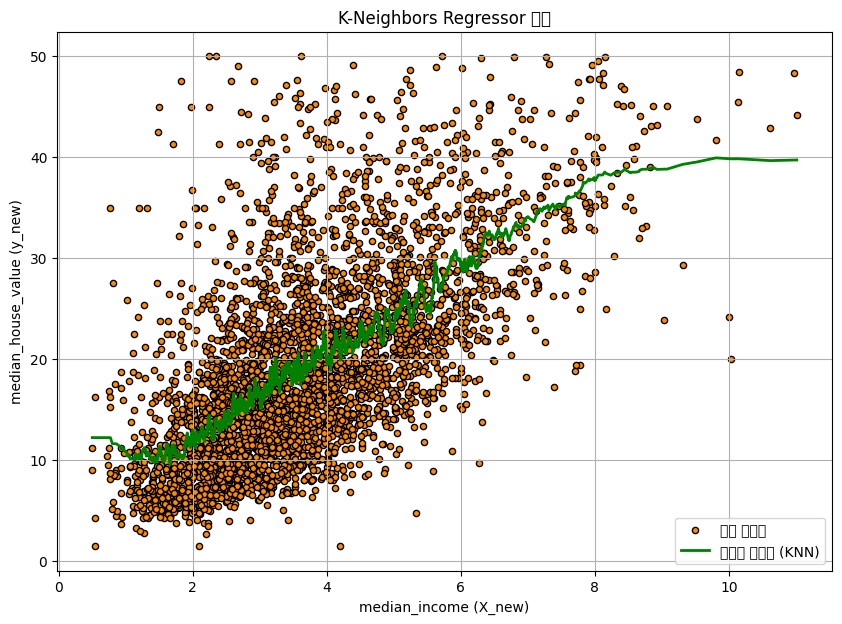

In [ ]:
# 예측 결과를 원래 데이터와 함께 시각화
plt.figure(figsize=(10, 7))
plt.scatter(test_input, test_target, s=20, edgecolor="black", c="darkorange", label="실제 데이터")

# 예측을 위한 정렬된 X 값
X_plot_knn = np.sort(test_input, axis=0)
y_plot_knn = model_knn.predict(X_plot_knn)

plt.plot(X_plot_knn, y_plot_knn, color="green", linewidth=2, label="예측된 회귀선 (KNN)")
plt.xlabel("median_income (X_new)")
plt.ylabel("median_house_value (y_new)")
plt.title("K-Neighbors Regressor 예측")
plt.legend()
plt.grid(True)
plt.show()

median_house_value와 가장 상관 관계가 높은 feature는 feature selection으로 알아본 결과 median_income이었습니다.

그래서 median_income을 이용해서 median_house_value를 예측하는 간단한 모델들을 만들어 보았습니다.

Linear regression 모델
- mse: MSE: 55.8980
- R-squared: 0.4108
- train score:0.4188583493232727
- test score:0.41079509258270264

Decision Tree regression 모델
- MSE: 56.6933
- R-squared: 0.4024
- train score: 0.43578132971873584
- test score: 0.40241190805712845

K-neighbors regression 모델
- MSE: 56.0474
- R-squared: 0.4092
- train score: 0.43401867151260376
- test score: 0.40922045707702637

세 가지 모델의 성능이 저조한 모습을 확인하실 수 있습니다.

제가 생각하는 모델의 성능이 저조한 이유는, 데이터가 너무 퍼져있다는 것입니다. 데이터 분포를 확인하기 위해 산점도를 그렸을 때 데이터가 굉장히 가로, 세로로 넓게 퍼져있었습니다. 그래서 모델이 회귀 곡선을 학습하여도 같은 정확도가 높은 값을 예측하기 어려움이 있는 것 같습니다.

더 정확도를 높히기 위해서는 더 많은 feature을 사용하여 예측을 수행하거나, 데이터가 퍼져있는 정도를 줄일 수 있는 전처리를 수행하거나, 퍼져있는 데이터도 잘 예측하는 알고리즘을 사용하여 모델을 만드는게 좋을 것 같습니다.